# Analyse Exploratoire

## Import des ibraries

In [1]:
import pandas as pd
import os
import glob
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
%matplotlib inline

## Chargement du dataset SILVER

In [2]:
repertoire_data_processed = Path.cwd().parent.parent / "data" / "processed"

try:
    path_dataset = next(repertoire_data_processed.glob("02_dataset_silver.csv"))
    print(f"Fichier trouvé : {path_dataset}")
    
    # Lecture
    df = pd.read_csv(path_dataset)
except StopIteration:
    print("Erreur : Le fichier '02_dataset_silver.csv' est introuvable dans le dossier.")

Fichier trouvé : /home/julien/Repos/fil_rouge-etude_chomage_france/data/processed/02_dataset_silver.csv


In [3]:
df['date'] = pd.to_datetime(df['date'])

In [4]:
# Apercu
df.head(150)

,date,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee,demandeur_total_abcd_total,demandeur_homme_abcd_total,demandeur_femme_abcd_total,...,taux_chomage_total_insee_diff,taux_chomage_ocde_diff,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_climat_affaires_diff,indicateur_climat_affaires_lag,taux_euribor_3m_diff,mro_diff,nb_interimaires_var,nb_defaillances_entreprise_var
0,2000-01-01,9.1,8.0,10.3,19.0,8.4,6.1,4018600.0,1774200.0,2244400.0,...,-0.4,-0.433333,1.723014,1.345448,-4.3,121.0,0.112500,0.416667,0.046137,-0.007076
1,2000-04-01,8.7,7.6,9.9,18.0,8.0,5.8,3890000.0,1701100.0,2188900.0,...,-0.4,-0.533333,1.754474,1.977185,0.3,116.7,0.720700,0.666667,0.046137,-0.141156
2,2000-07-01,8.4,7.2,9.6,17.4,7.8,5.5,3807900.0,1659300.0,2148600.0,...,-0.3,-0.433333,1.901287,1.861366,1.4,117.0,0.474600,0.333333,0.016013,-0.148986
3,2000-10-01,8.0,6.9,9.4,16.9,7.5,5.2,3690300.0,1601400.0,2088900.0,...,-0.4,-0.366667,1.492307,1.966656,-3.9,118.4,0.286567,0.000000,-0.021358,0.328532
4,2001-01-01,7.8,6.6,9.2,16.8,7.3,4.9,3609400.0,1565300.0,2044100.0,...,-0.2,-0.200000,1.376954,1.819251,-1.1,114.5,-0.279133,0.000000,0.039423,-0.244370
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
98,2024-07-01,7.4,7.6,7.1,19.7,6.6,4.7,5412400.0,2637700.0,2774700.0,...,0.1,0.033333,-0.300908,-0.160190,-2.2,99.6,-0.252833,-0.366667,-0.011181,-0.162955
99,2024-10-01,7.3,7.4,7.1,18.7,6.6,4.7,5491700.0,2678900.0,2812800.0,...,-0.1,-0.100000,-0.552588,-0.381298,-2.4,97.4,-0.558867,-0.733333,-0.017005,0.337962
100,2025-01-01,7.5,7.5,7.4,19.2,6.8,4.8,5738000.0,2811000.0,2927000.0,...,0.2,0.166667,-0.384802,-0.391827,1.6,95.0,-0.439667,-0.416667,-0.004978,-0.013529
101,2025-04-01,7.6,7.7,7.4,19.1,6.9,4.8,5612100.0,2749800.0,2862300.0,...,0.1,0.100000,-0.447721,-0.191777,-0.6,96.6,-0.449133,-0.583333,-0.000738,-0.047422


## Re-vérification des caractéristiques du dataframe

In [5]:
# Shape
print(f"Nombre de colonnes : {len(df.columns)}")
print(f"Nombre de lignes : {len(df)}")

Nombre de colonnes : 50
Nombre de lignes : 103


Quelles sont les variables catégorielles ? Les variables numériques ? 

In [6]:
# type de colonnes
df.dtypes

# UNIQUEMENT DES VARIABLES NUMERIQUES

date                                    datetime64[us]
taux_chomage_total_insee                       float64
taux_chomage_homme_insee                       float64
taux_chomage_femme_insee                       float64
taux_chomage_15_24_insee                       float64
taux_chomage_25_49_insee                       float64
taux_chomage_50_plus_insee                     float64
demandeur_total_abcd_total                     float64
demandeur_homme_abcd_total                     float64
demandeur_femme_abcd_total                     float64
demandeur_total_abcd_moins25                   float64
demandeur_total_abcd_2549                      float64
demandeur_total_abcd_plus50                    float64
demandeur_homme_abcd_moins25                   float64
demandeur_homme_abcd_2549                      float64
demandeur_homme_abcd_plus50                    float64
demandeur_femme_abcd_moins25                   float64
demandeur_femme_abcd_2549                      float64
demandeur_

In [7]:
df.iloc[:, 0:7].describe()

# Commentaire(s) :
### RAS

,date,taux_chomage_total_insee,taux_chomage_homme_insee,taux_chomage_femme_insee,taux_chomage_15_24_insee,taux_chomage_25_49_insee,taux_chomage_50_plus_insee
count,103,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,2012-09-30 13:02:54.757281,8.678641,8.480583,8.903883,21.717476,7.857282,5.615534
min,2000-01-01 00:00:00,7.100000,6.500000,6.800000,16.500000,6.300000,4.100000
25%,2006-05-16 12:00:00,7.800000,7.550000,8.050000,19.000000,7.200000,5.050000
50%,2012-10-01 00:00:00,8.800000,8.200000,9.200000,21.800000,7.900000,5.500000
75%,2019-02-15 00:00:00,9.300000,9.250000,9.700000,24.650000,8.400000,6.250000
max,2025-07-01 00:00:00,10.500000,11.000000,10.400000,27.900000,9.700000,7.200000
std,NaN,0.994066,1.180649,0.999796,3.199768,0.935425,0.767445


In [8]:
df.iloc[:, 8:19].describe()

# Commentaire(s) :
### RAS

,demandeur_homme_abcd_total,demandeur_femme_abcd_total,demandeur_total_abcd_moins25,demandeur_total_abcd_2549,demandeur_total_abcd_plus50,demandeur_homme_abcd_moins25,demandeur_homme_abcd_2549,demandeur_homme_abcd_plus50,demandeur_femme_abcd_moins25,demandeur_femme_abcd_2549,demandeur_femme_abcd_plus50
count,1.030000e+02,1.030000e+02,103.000000,1.030000e+02,1.030000e+02,103.000000,1.030000e+02,103.000000,103.000000,1.030000e+02,103.000000
mean,2.285973e+06,2.475779e+06,716825.242718,3.021532e+06,1.023394e+06,357899.029126,1.441559e+06,486514.563107,358926.213592,1.579973e+06,536879.611650
std,4.965842e+05,4.445468e+05,79514.584577,4.654182e+05,4.233691e+05,49824.508685,2.622320e+05,201249.082038,31815.072150,2.114655e+05,222305.274279
min,1.499000e+06,1.746200e+06,550800.000000,2.186700e+06,5.057000e+05,257900.000000,1.007300e+06,230700.000000,292100.000000,1.179400e+06,274700.000000
25%,1.806800e+06,2.073700e+06,661750.000000,2.621100e+06,5.927000e+05,326050.000000,1.201200e+06,282250.000000,331300.000000,1.409200e+06,309250.000000
50%,2.400400e+06,2.482100e+06,722700.000000,3.085600e+06,9.912000e+05,362900.000000,1.517100e+06,475200.000000,360100.000000,1.573700e+06,516000.000000
75%,2.767350e+06,2.885750e+06,782650.000000,3.489650e+06,1.486150e+06,394350.000000,1.687700e+06,704700.000000,386200.000000,1.776050e+06,779900.000000
max,2.968900e+06,3.138300e+06,866800.000000,3.710700e+06,1.597700e+06,453800.000000,1.805600e+06,753800.000000,413000.000000,1.905100e+06,843900.000000


In [9]:
df.iloc[:, 20:33].describe()

# Commentaire(s) :
### RAS

,pib,ict,nb_interimaires,taux_euribor_3m,mro,ipc,isj,ipc_energie_only,taux_chomage_ocde,nb_defaillances_entreprise,indicateur_climat_affaires,indicateur_climat_emploi,indicateur_retournement_conjoncturel
count,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,572790.475728,87.980583,661273.427517,1.622106,2.066505,1.690291,1.409709,4.062460,8.788673,13158.330097,100.908738,101.481553,0.270583
std,48875.755933,12.852611,89845.599252,1.783065,1.891008,1.273935,1.091616,8.126612,0.967698,2906.614753,8.942377,9.473831,0.764716
min,480413.000000,64.000000,477838.210451,-0.566400,0.000000,-0.433333,-0.066667,-16.100000,7.100000,5434.000000,69.100000,68.400000,-1.000000
25%,541058.000000,78.150000,593762.607550,-0.137617,0.041667,0.983333,0.733333,-0.900000,8.066667,11564.000000,95.500000,95.650000,-0.600000
50%,570781.000000,90.100000,640411.444797,1.411633,1.250000,1.633333,1.233333,3.400000,8.833333,13290.000000,102.000000,102.000000,0.800000
75%,610386.500000,97.500000,730857.542042,3.288900,4.250000,2.083333,1.700000,10.500000,9.433333,15234.500000,107.150000,108.300000,0.900000
max,661062.000000,112.800000,821378.102512,5.024167,4.500000,6.100000,5.833333,29.133333,10.466667,18612.000000,118.400000,118.900000,1.000000


In [10]:
df.iloc[:, 34:].describe()

# Commentaire(s) :
### Problème précédent avec ipc_yoy qui faisait une différence en % et générait une valeur "infinie" pour le 2ème trimestre 2017 
### --> utilisation de la fonction .diff() pour obtenir une différence en point (absolue).

,pib_qoq,pib_logdiff,ipc_yoy,ipc_energie_only_yoy,isj_var,ict_var,taux_chomage_total_insee_diff,taux_chomage_ocde_diff,indicateur_climat_affaires_zscore,indicateur_climat_emploi_zscore,indicateur_climat_affaires_diff,indicateur_climat_affaires_lag,taux_euribor_3m_diff,mro_diff,nb_interimaires_var,nb_defaillances_entreprise_var
count,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000,103.000000
mean,0.003410,0.003193,0.020518,-0.186278,0.010280,0.005645,-0.017476,-0.028803,0.067040,0.143207,-0.243689,101.152427,-0.013769,-0.006634,0.003579,0.019266
std,0.020838,0.020633,1.404171,11.797987,0.543641,0.008513,0.322499,0.292687,0.937755,0.997494,4.605020,9.144267,0.380054,0.310556,0.059631,0.194379
min,-0.122197,-0.130333,-3.700000,-31.533333,-3.500000,-0.045543,-0.900000,-0.766667,-3.268628,-3.339930,-16.200000,69.100000,-2.202967,-1.333333,-0.382981,-0.450831
25%,0.000826,0.000826,-0.666667,-7.450000,-0.145503,0.003172,-0.200000,-0.150000,-0.500155,-0.470794,-2.450000,95.500000,-0.096517,0.000000,-0.014512,-0.133362
50%,0.003571,0.003565,-0.100000,-2.333333,0.000000,0.006562,0.000000,-0.033333,0.181477,0.197794,-0.100000,102.200000,-0.004667,0.000000,0.003300,-0.036606
75%,0.006438,0.006418,0.716667,6.983333,0.134848,0.008690,0.100000,0.116667,0.721539,0.861117,2.150000,107.200000,0.108667,0.000000,0.031427,0.178711
max,0.153466,0.142772,4.100000,28.066667,2.000000,0.044534,1.900000,1.600000,1.901287,1.977185,17.000000,121.000000,1.291400,1.166667,0.224137,0.485646


### Vérification de la colonne `ipc_yoy`

In [11]:
df["ipc_yoy"].unique()
# OK

array([ 1.24666667,  1.06666667,  1.36666667,  0.9       , -0.16666667,
        0.63333333, -0.13333333, -0.46666667,  0.86666667, -0.43333333,
        0.        ,  0.7       ,  0.2       ,  0.3       ,  0.03333333,
       -0.56666667,  0.46666667,  0.33333333, -0.06666667, -0.1       ,
       -0.66666667, -0.43333333, -0.4       ,  0.1       , -0.16666667,
       -0.36666667, -0.66666667, -0.73333333, -0.43333333,  1.        ,
        1.8       ,  2.1       ,  2.        , -2.3       , -3.53333333,
       -3.7       , -1.4       ,  1.83333333,  2.        ,  1.3       ,
        0.46666667,  0.46666667,  0.53333333,  0.76666667, -0.06666667,
       -0.13333333, -0.9       , -1.26666667, -1.2       , -1.        ,
       -0.86666667, -0.36666667, -0.16666667, -0.56666667, -0.96666667,
       -0.4       , -0.33333333, -0.2       ,  0.23333333, -0.23333333,
        0.2       ,  0.4       ,  1.23333333,  0.9       ,  0.6       ,
        0.66666667,  0.16666667,  0.96666667,  1.4       ,  0.73

## Vérification des valeurs manquantes

In [12]:
df.isna().any()

date                                    False
taux_chomage_total_insee                False
taux_chomage_homme_insee                False
taux_chomage_femme_insee                False
taux_chomage_15_24_insee                False
taux_chomage_25_49_insee                False
taux_chomage_50_plus_insee              False
demandeur_total_abcd_total              False
demandeur_homme_abcd_total              False
demandeur_femme_abcd_total              False
demandeur_total_abcd_moins25            False
demandeur_total_abcd_2549               False
demandeur_total_abcd_plus50             False
demandeur_homme_abcd_moins25            False
demandeur_homme_abcd_2549               False
demandeur_homme_abcd_plus50             False
demandeur_femme_abcd_moins25            False
demandeur_femme_abcd_2549               False
demandeur_femme_abcd_plus50             False
population_active                       False
pib                                     False
ict                               

# EXPLORATION DES DONNÉES

### Evolution du Taux de Chômage en France (INSEE)

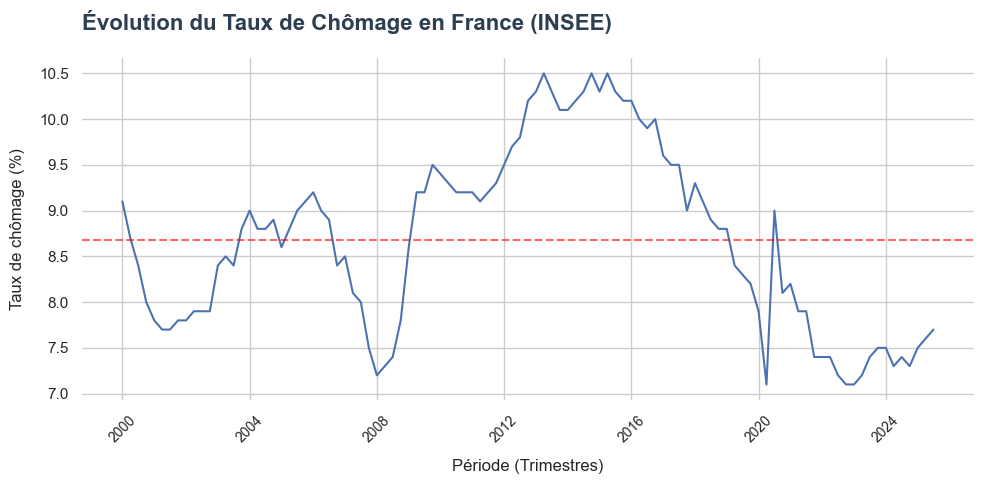

In [13]:
# 1. Configuration du style
sns.set_theme(style="whitegrid") # Fond propre avec grille discrète
plt.figure(figsize=(10, 5))

plt.title("Évolution du Taux de Chômage en France (INSEE)", 
          fontsize=16, fontweight='bold', pad=20, loc='left', color='#2c3e50')

plt.xlabel("Période (Trimestres)", fontsize=12, labelpad=10)
plt.ylabel("Taux de chômage (%)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='center', fontsize=10)

sns.despine(left=True, bottom=True)
sns.lineplot(x="date", y="taux_chomage_total_insee", data=df, estimator=np.mean)
mean_val = df['taux_chomage_total_insee'].mean()
plt.axhline(mean_val, color='red', linestyle='--', alpha=0.6, label=f"Moyenne : {mean_val:.1f}%")
plt.tight_layout()
plt.show()

### Evolution du Taux de Chômage en France (OCDE)

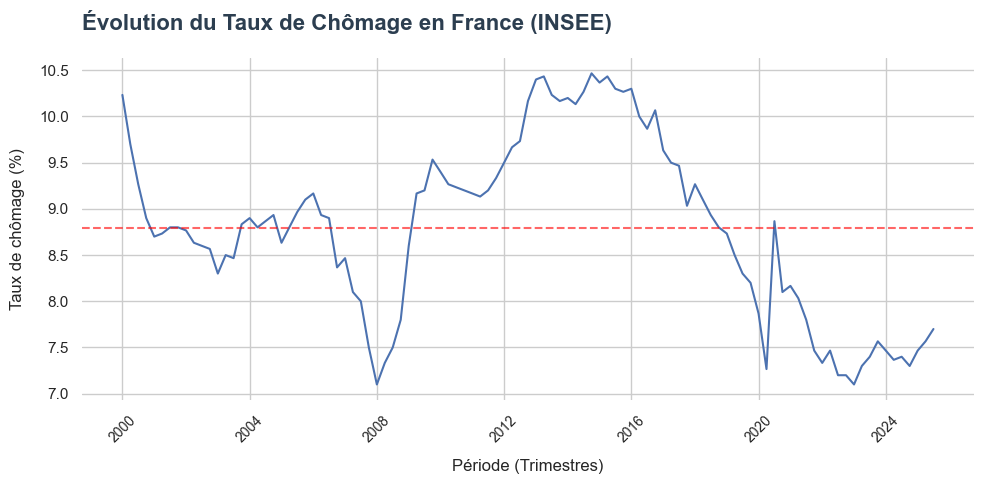

In [14]:
# 1. Configuration du style
sns.set_theme(style="whitegrid") # Fond propre avec grille discrète
plt.figure(figsize=(10, 5))

plt.title("Évolution du Taux de Chômage en France (INSEE)", 
          fontsize=16, fontweight='bold', pad=20, loc='left', color='#2c3e50')

plt.xlabel("Période (Trimestres)", fontsize=12, labelpad=10)
plt.ylabel("Taux de chômage (%)", fontsize=12, labelpad=10)
plt.xticks(rotation=45, ha='center', fontsize=10)

sns.despine(left=True, bottom=True)
sns.lineplot(x="date", y="taux_chomage_ocde", data=df, estimator=np.mean)
mean_val = df['taux_chomage_ocde'].mean()
plt.axhline(mean_val, color='red', linestyle='--', alpha=0.6, label=f"Moyenne : {mean_val:.1f}%")
plt.tight_layout()
plt.show()

Commentaire : OCDE et INSEE sont alignés. 

# Matrice de corrélation

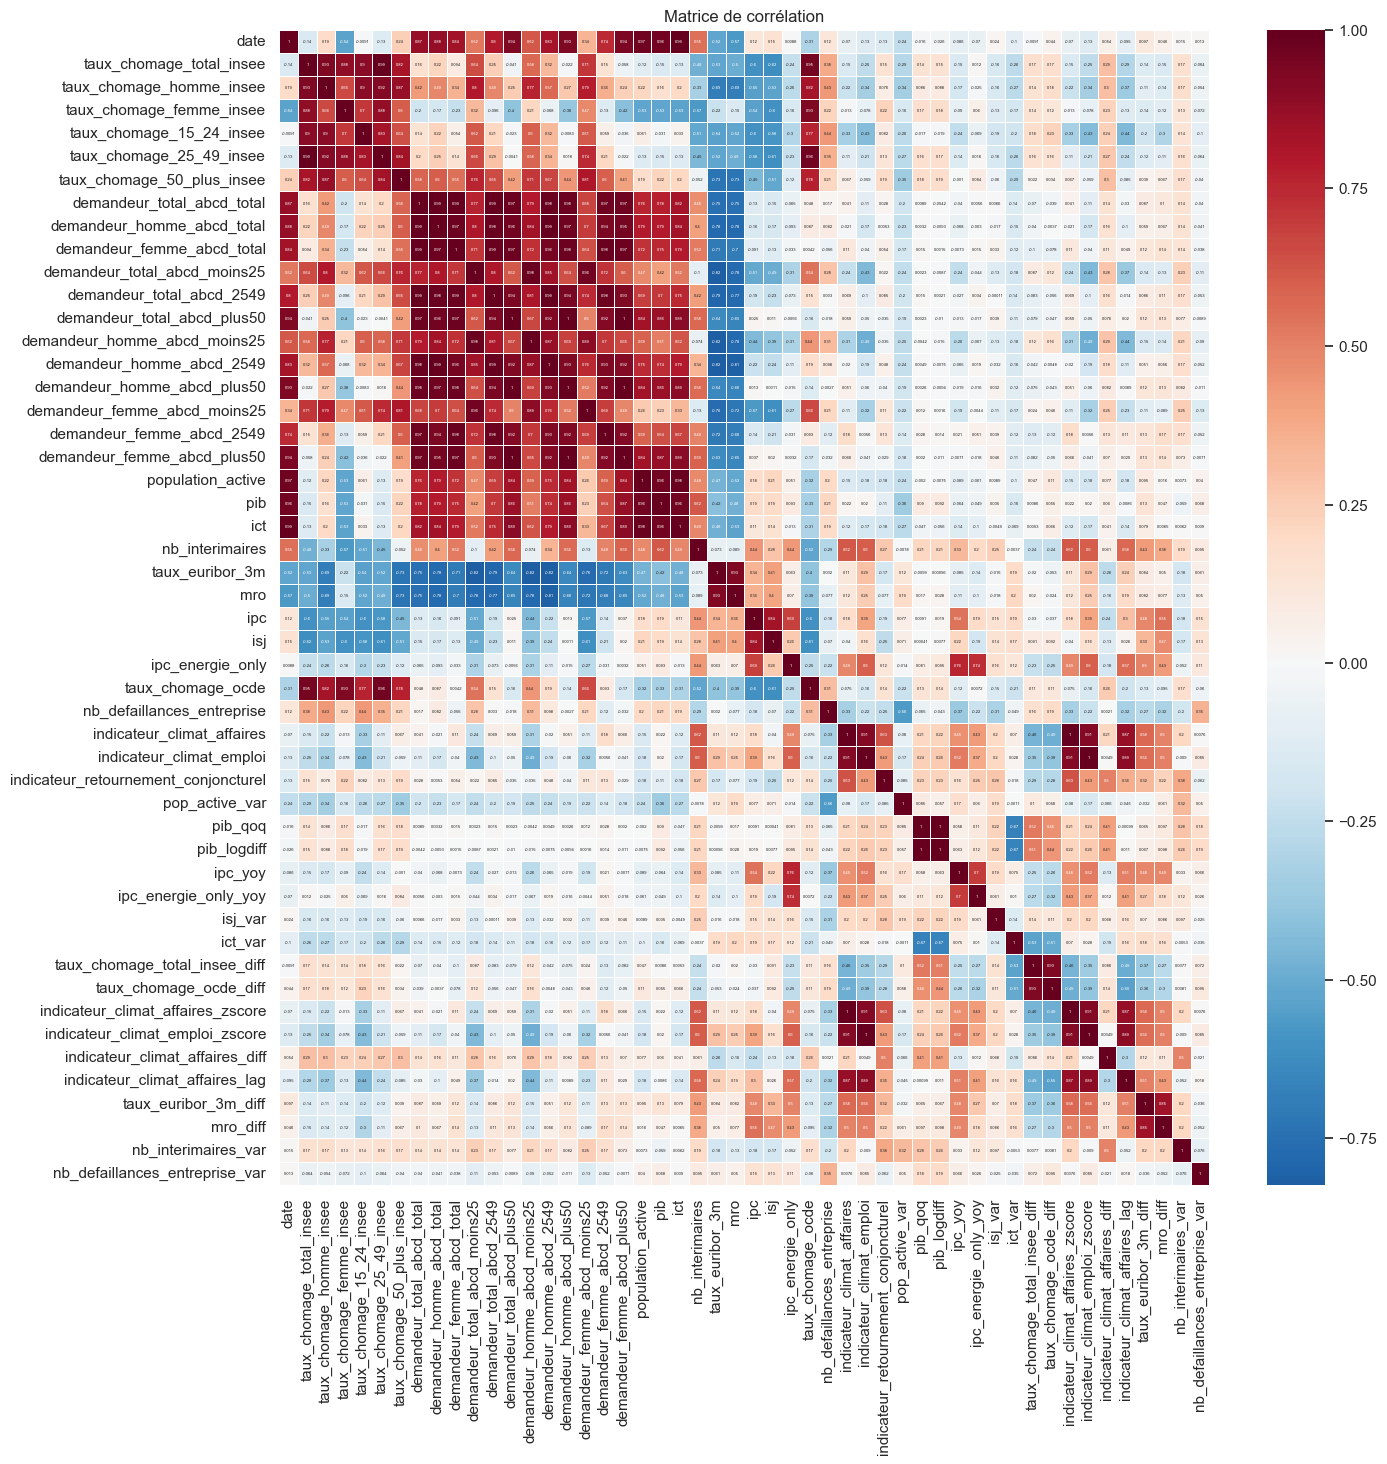

In [30]:
plt.figure(figsize=(15, 15))
df_corr = df.corr()

ax = sns.heatmap(df_corr, annot=True, cmap='RdBu_r', center=0, linewidths=0.5,annot_kws={'size': 3})
ax.figure.axes[-1].yaxis.label.set_size(10)
plt.title('Matrice de corrélation')
plt.show()



In [32]:
df_corr_chomage_insee = df.corr()['taux_chomage_total_insee']
print(df_corr_chomage_insee)

date                                   -0.141511
taux_chomage_total_insee                1.000000
taux_chomage_homme_insee                0.931717
taux_chomage_femme_insee                0.884236
taux_chomage_15_24_insee                0.895139
taux_chomage_25_49_insee                0.985755
taux_chomage_50_plus_insee              0.819563
demandeur_total_abcd_total              0.159973
demandeur_homme_abcd_total              0.216569
demandeur_femme_abcd_total              0.094437
demandeur_total_abcd_moins25            0.644496
demandeur_total_abcd_2549               0.248556
demandeur_total_abcd_plus50            -0.041106
demandeur_homme_abcd_moins25            0.576233
demandeur_homme_abcd_2549               0.317529
demandeur_homme_abcd_plus50            -0.022023
demandeur_femme_abcd_moins25            0.708352
demandeur_femme_abcd_2549               0.153293
demandeur_femme_abcd_plus50            -0.058347
population_active                      -0.116343
pib                 

In [33]:
# Filtrage des corrélations positives supérieures à 0,2 OU des corrélations négatives inférieures à -0,2
print(df_corr_chomage_insee[(df_corr_chomage_insee > 0.2) | (df_corr_chomage_insee < -0.2)])

taux_chomage_total_insee           1.000000
taux_chomage_homme_insee           0.931717
taux_chomage_femme_insee           0.884236
taux_chomage_15_24_insee           0.895139
taux_chomage_25_49_insee           0.985755
taux_chomage_50_plus_insee         0.819563
demandeur_homme_abcd_total         0.216569
demandeur_total_abcd_moins25       0.644496
demandeur_total_abcd_2549          0.248556
demandeur_homme_abcd_moins25       0.576233
demandeur_homme_abcd_2549          0.317529
demandeur_femme_abcd_moins25       0.708352
nb_interimaires                   -0.479583
taux_euribor_3m                   -0.531130
mro                               -0.495278
ipc                               -0.596794
isj                               -0.619890
ipc_energie_only                  -0.236586
taux_chomage_ocde                  0.952564
nb_defaillances_entreprise         0.377723
indicateur_climat_emploi          -0.247014
pop_active_var                    -0.285755
ict_var                         

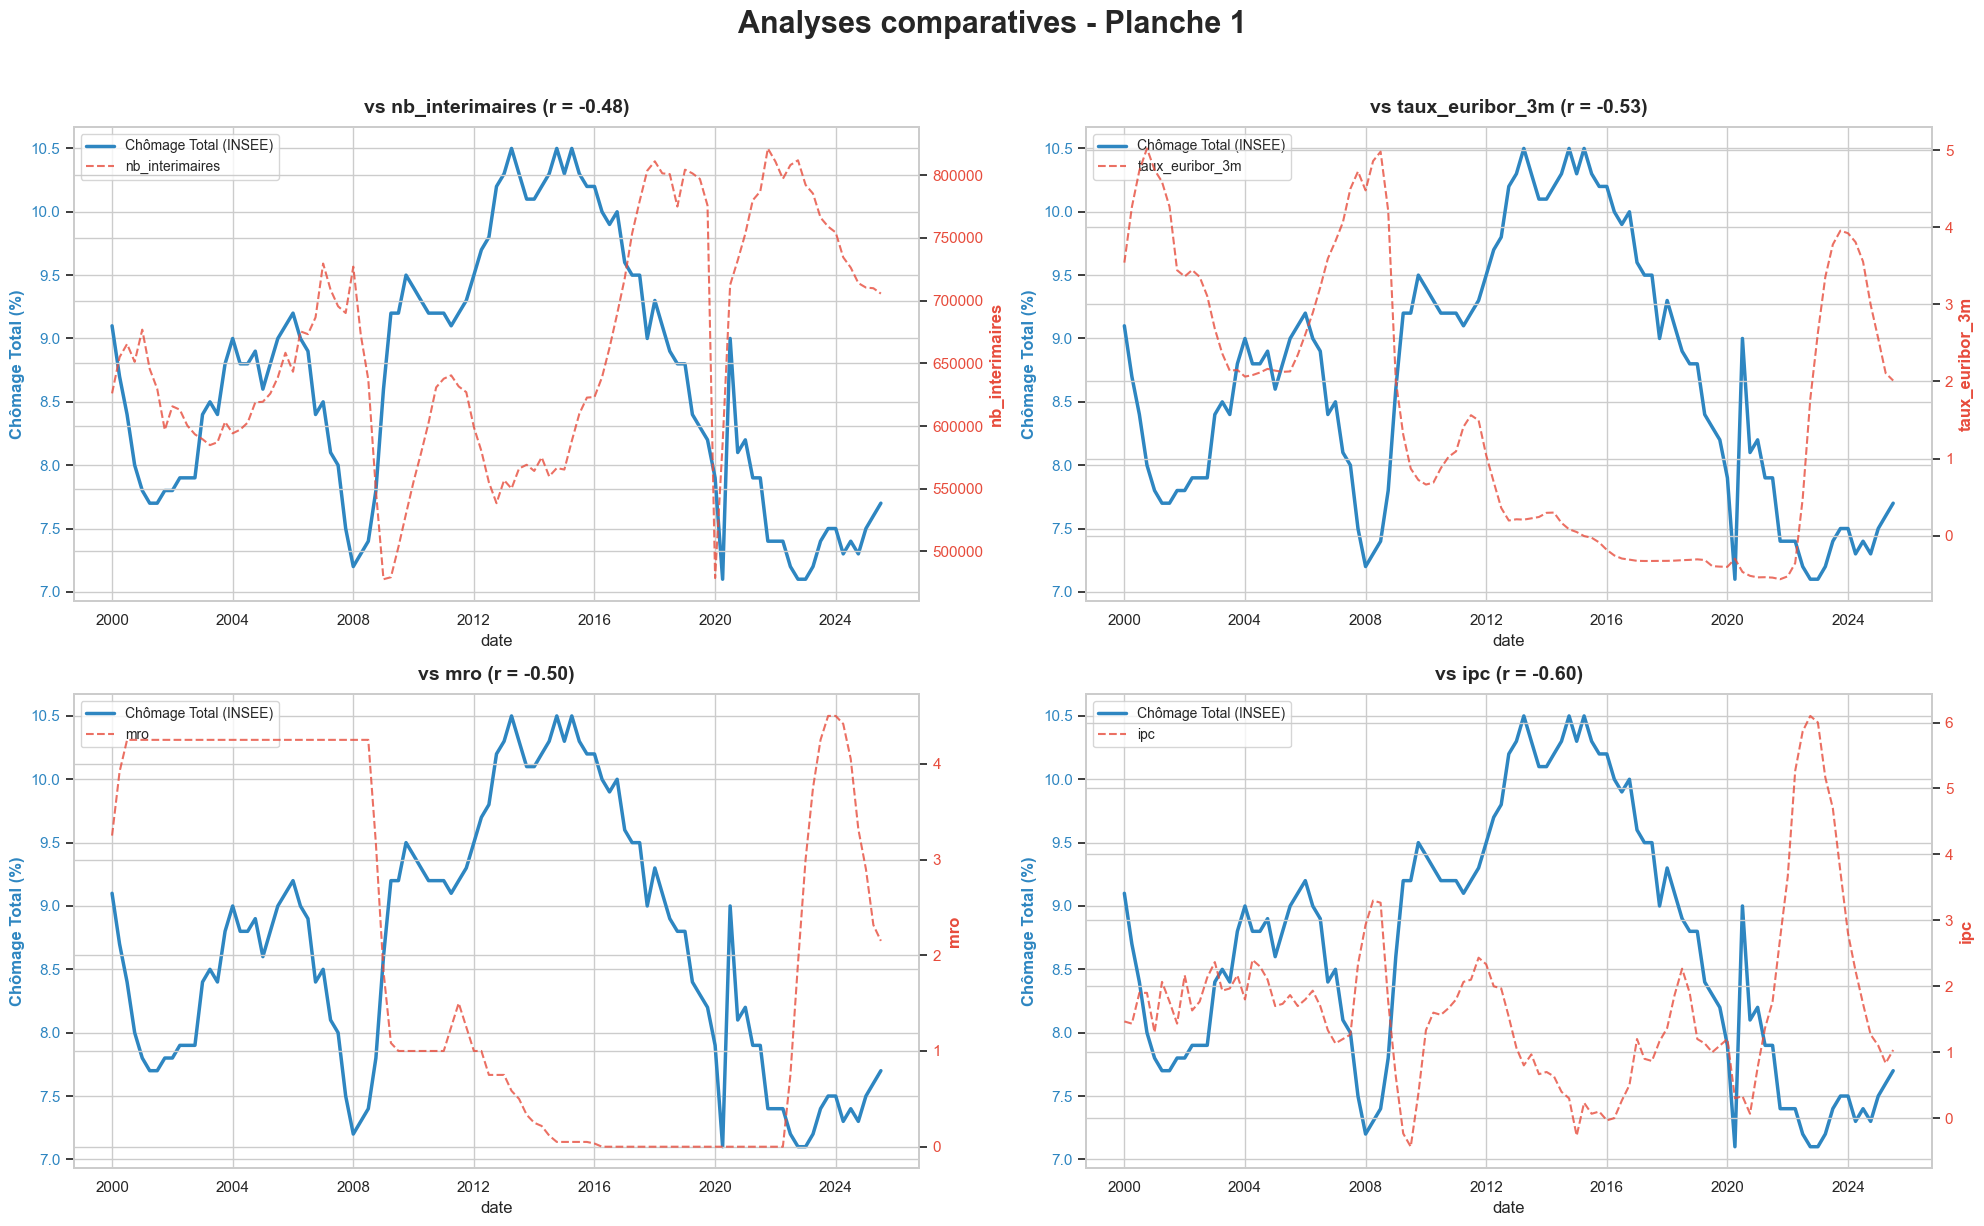

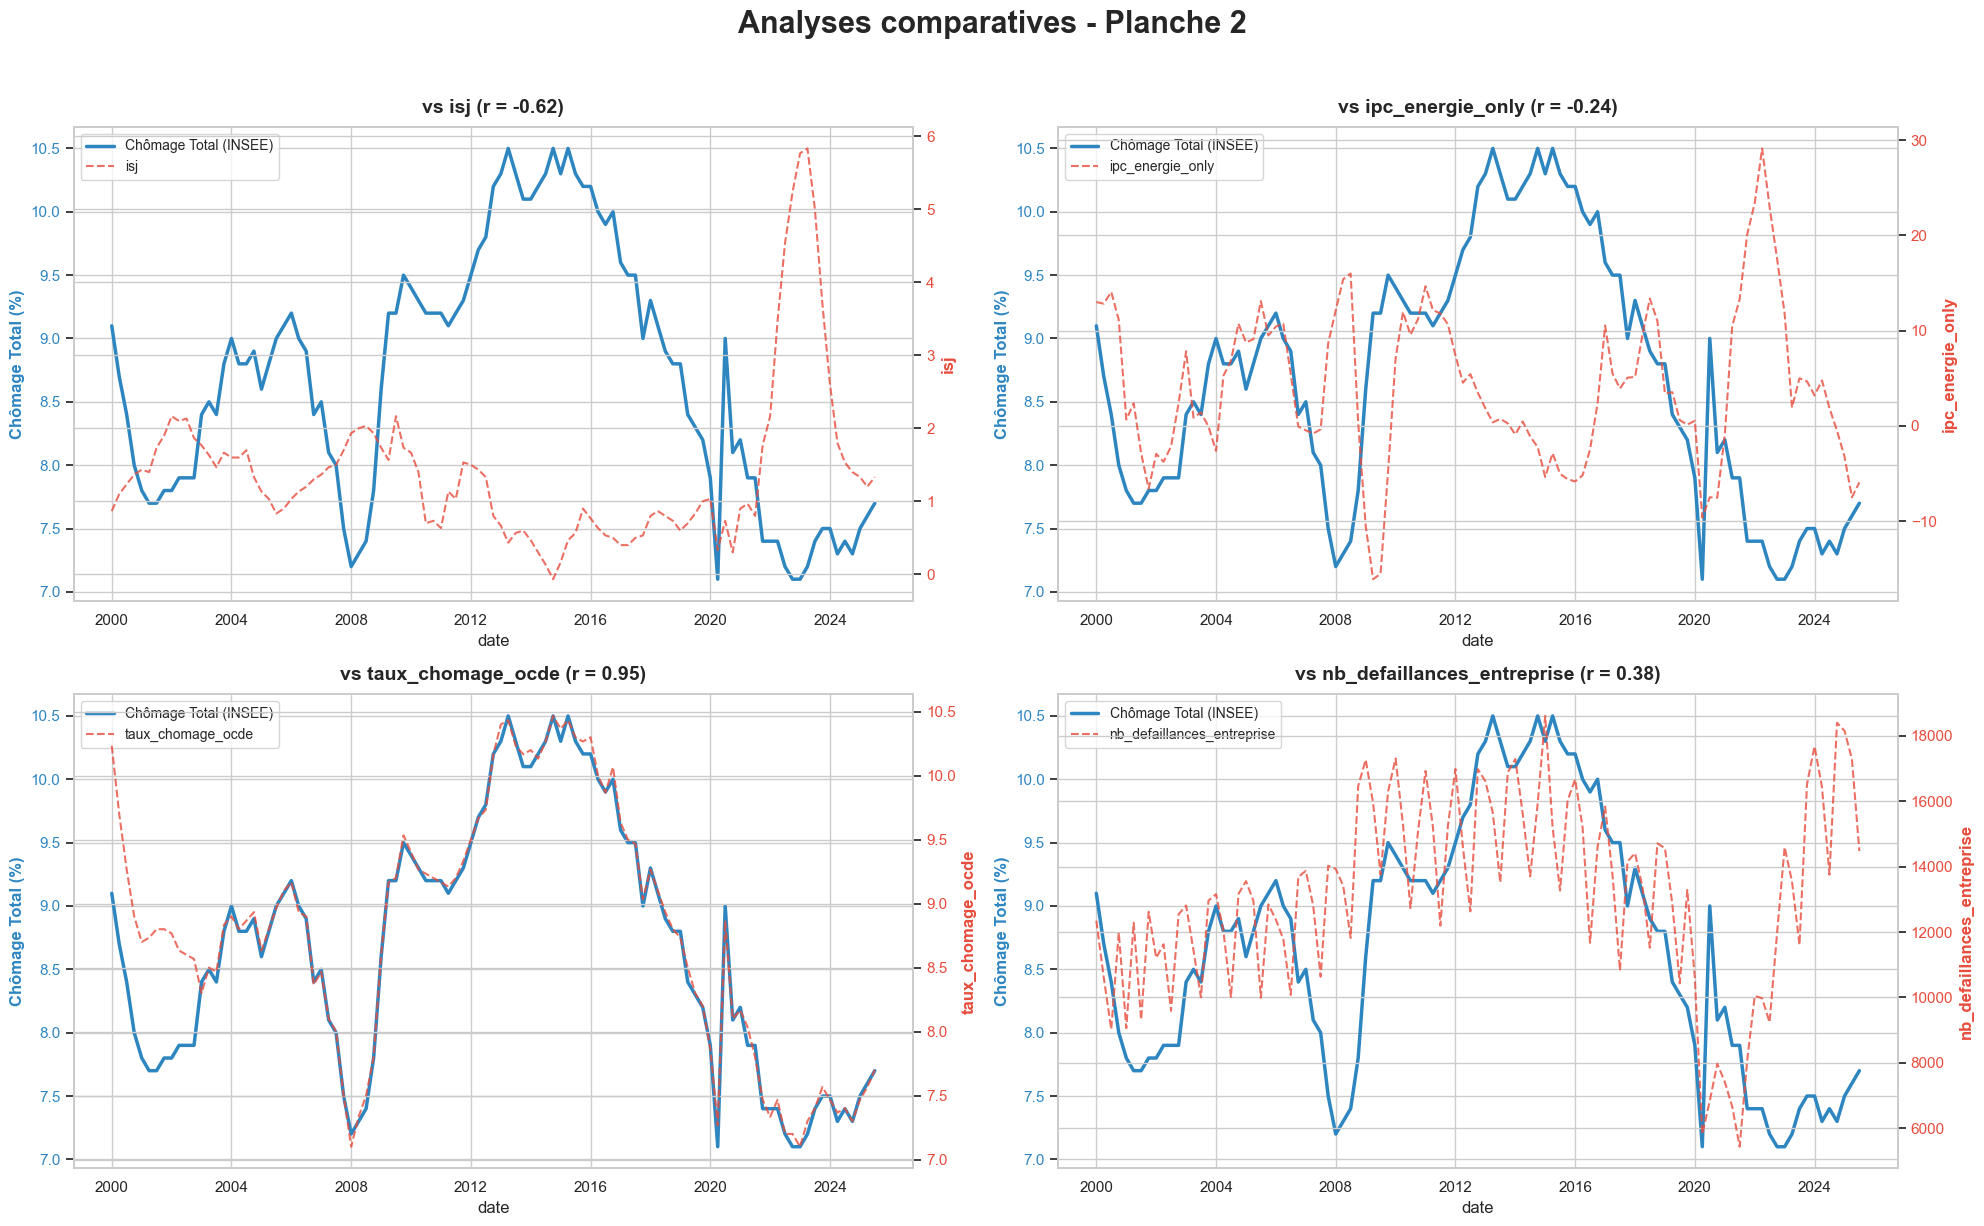

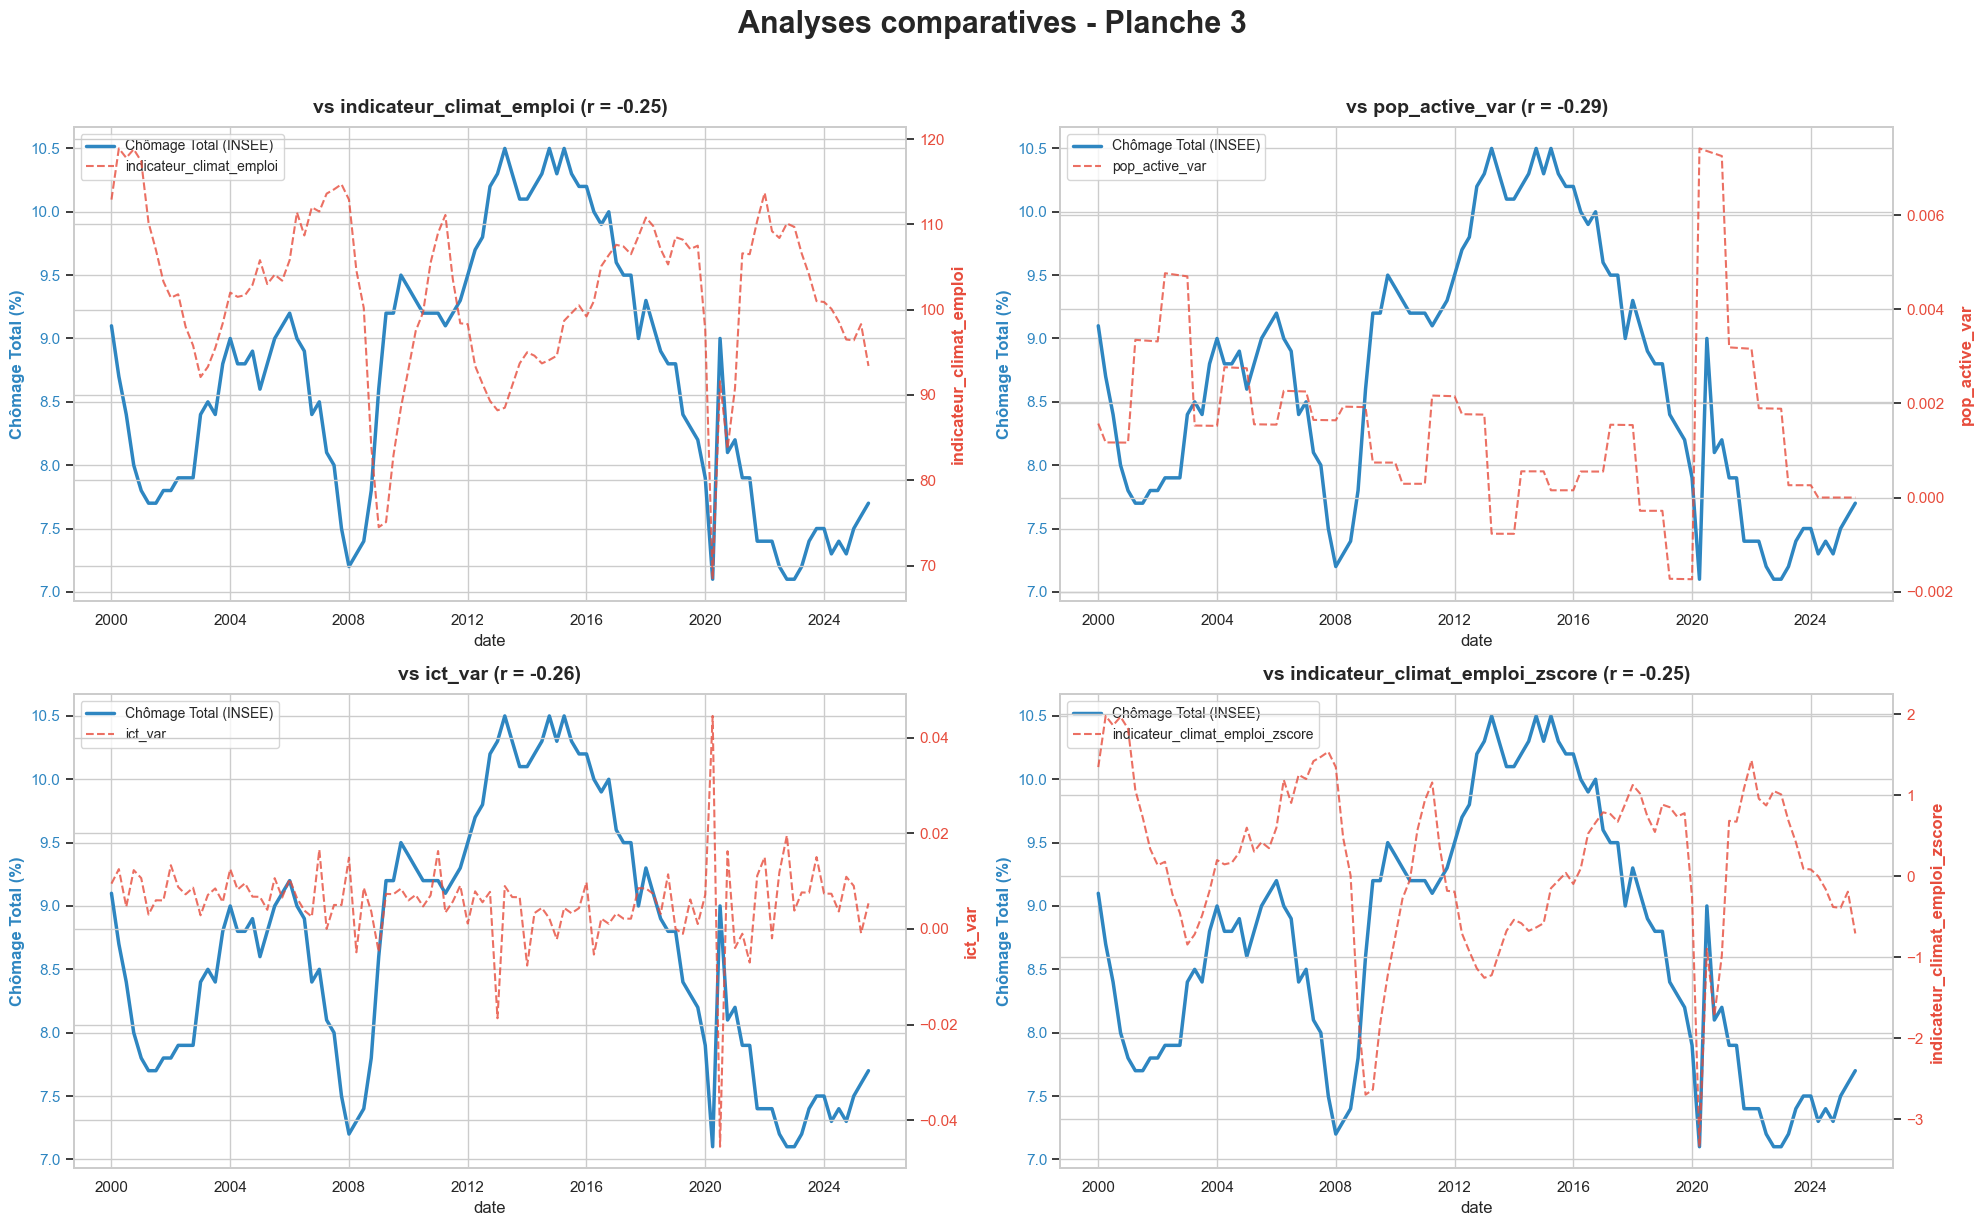

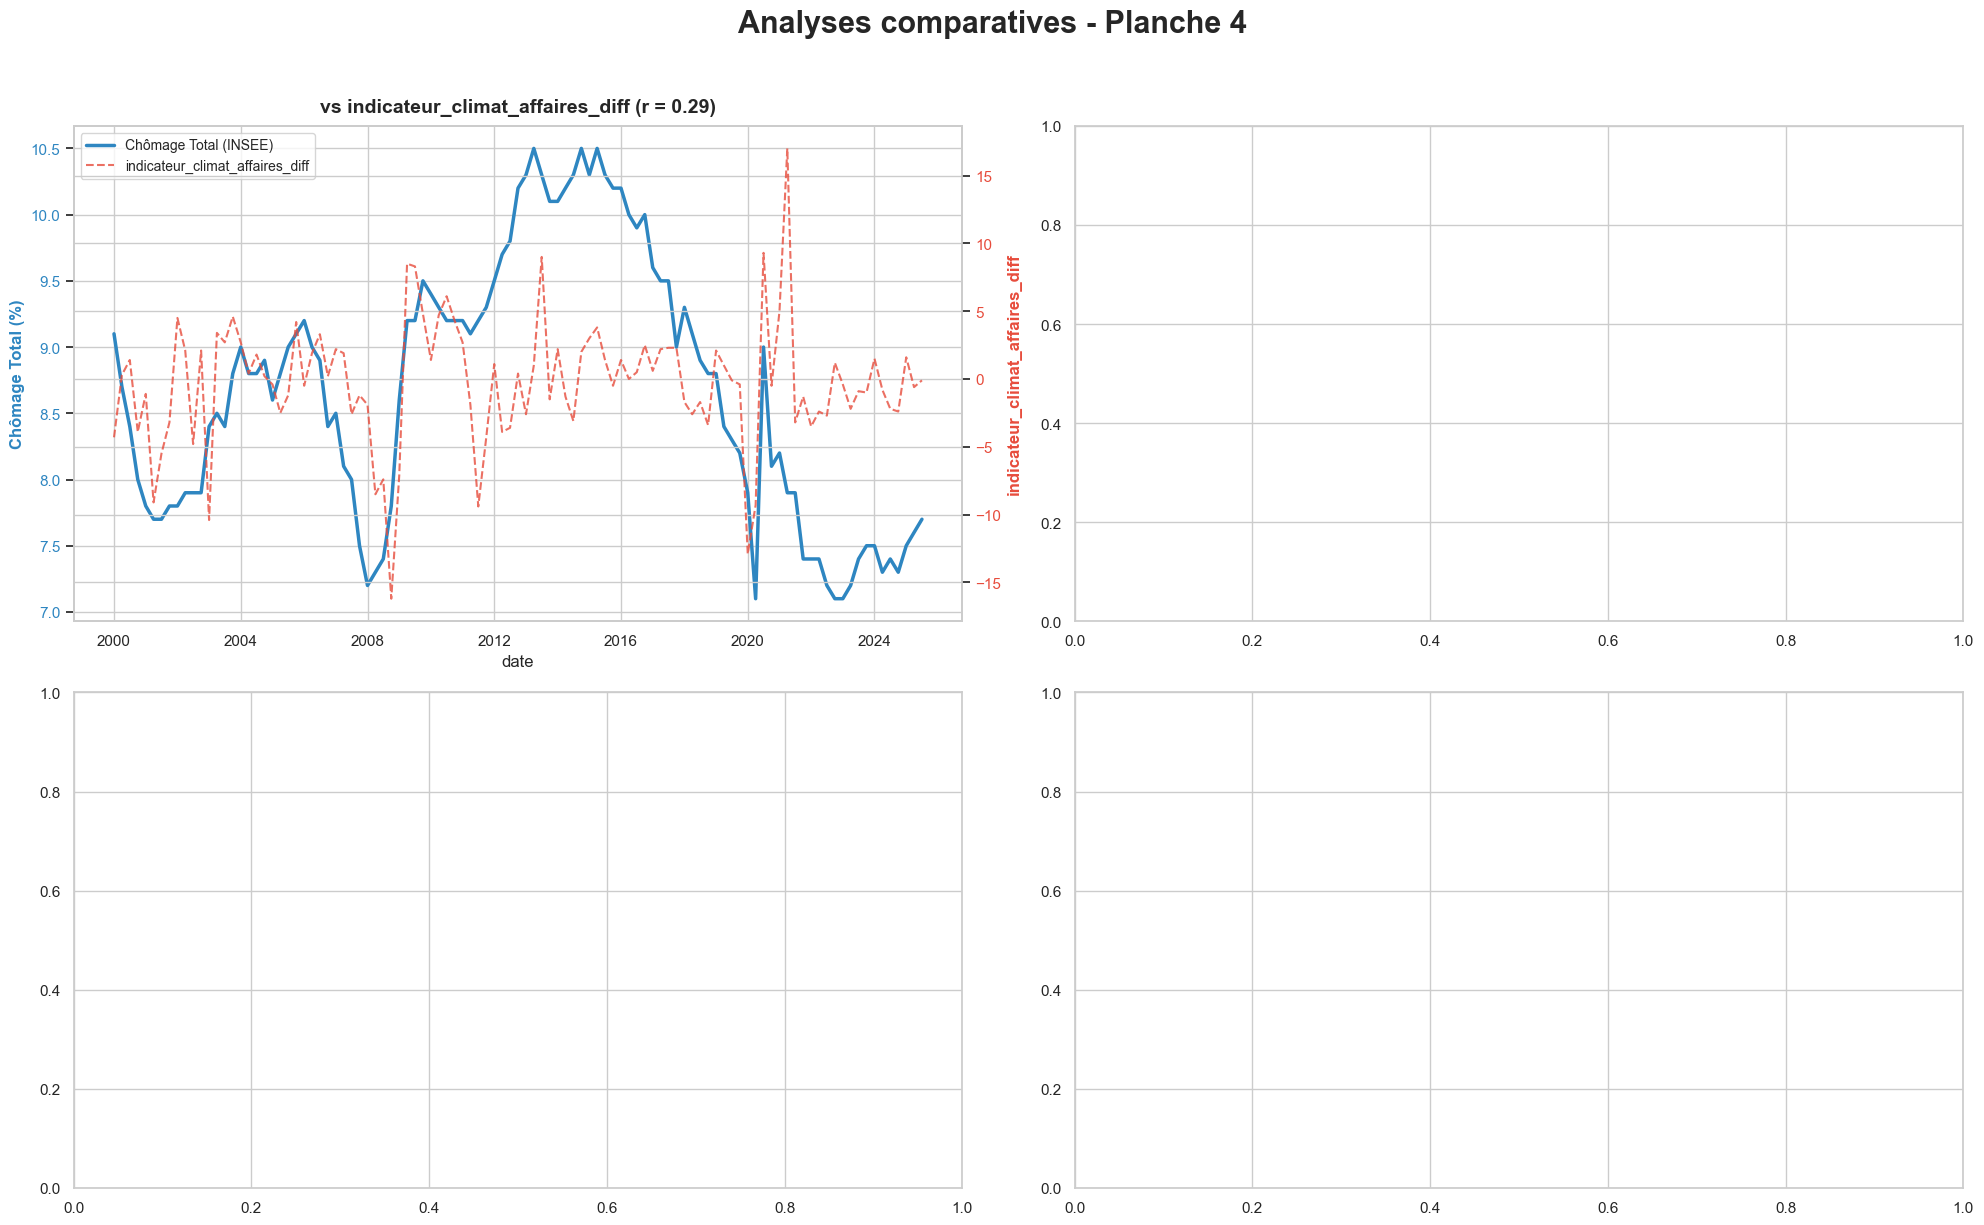

In [38]:
# 3. Liste des colonnes à comparer (basée sur ton filtre > 0.2 ou < -0.2)
cols_to_compare = [
    "nb_interimaires",
    "taux_euribor_3m", "mro", "ipc", "isj", "ipc_energie_only", "taux_chomage_ocde",
    "nb_defaillances_entreprise", "indicateur_climat_emploi", "pop_active_var",
    "ict_var", "indicateur_climat_emploi_zscore", "indicateur_climat_affaires_diff"
]

target = "taux_chomage_total_insee"
sns.set_theme(style="whitegrid")
color_target = '#2E86C1' # Bleu
color_feature = '#E74C3C' # Rouge

# 4. Génération des graphiques par groupes de 4
for i in range(0, len(cols_to_compare), 4):
    subset = [c for c in cols_to_compare[i:i+4] if c in df.columns]
    if not subset: continue
    
    fig, axes = plt.subplots(2, 2, figsize=(20, 12))
    axes = axes.flatten()
    
    for j, col in enumerate(subset):
        ax1 = axes[j]
        # Récupération du taux de corrélation
        corr_val = df_corr_chomage_insee[col]
        
        # Courbe 1 : Chômage (Axe Gauche)
        sns.lineplot(data=df, x='date', y=target, ax=ax1, color=color_target, 
                     label='Chômage Total (INSEE)', linewidth=2.5)
        ax1.set_ylabel('Chômage Total (%)', color=color_target, fontweight='bold')
        ax1.tick_params(axis='y', labelcolor=color_target)
        
        # Courbe 2 : Variable comparée (Axe Droit)
        ax2 = ax1.twinx()
        sns.lineplot(data=df, x='date', y=col, ax=ax2, color=color_feature, 
                     label=col, linestyle='--', alpha=0.8, linewidth=1.5)
        ax2.set_ylabel(col, color=color_feature, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor=color_feature)
        
        # TITRE : Ajout du nom de la colonne et du coefficient de corrélation
        ax1.set_title(f"vs {col} (r = {corr_val:.2f})", fontsize=14, fontweight='bold', pad=10)
        
        # Gestion des légendes
        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize='small')
        if ax2.get_legend(): ax2.get_legend().remove()

    plt.suptitle(f"Analyses comparatives - Planche {i//4 + 1}", 
                 fontsize=22, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show() # Remplace plt.close() par plt.show()